# TIPOS DE BALANCEO MODELOS

En este notebook se probaran diferentes metodos de balanceo de datos, al tener en cuenta el desbalanceo que presenta el dataset 

### IMPORTS

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.append(os.path.abspath(".."))
ruta_datos = "../Datos_preparados_iomt2024"

x_train_binario = pd.read_csv(f"{ruta_datos}/binario_train_X.csv")
y_train_binario = pd.read_csv(f"{ruta_datos}/binario_train_Y.csv").squeeze()

x_val_binario = pd.read_csv(f"{ruta_datos}/binario_val_X.csv")
y_val_binario = pd.read_csv(f"{ruta_datos}/binario_val_Y.csv").squeeze()

x_test_known_binario = pd.read_csv(f"{ruta_datos}/binario_test_known_X.csv")
y_test_known_binario = pd.read_csv(f"{ruta_datos}/binario_test_known_Y.csv").squeeze()

x_test_zeroday_binario = pd.read_csv(f"{ruta_datos}/binario_test_zeroday_X.csv")
y_test_zeroday_binario = pd.read_csv(f"{ruta_datos}/binario_test_zeroday_Y.csv").squeeze()

x_train_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_train_X.csv")
y_train_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_train_Y.csv").squeeze()

x_val_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_val_X.csv")
y_val_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_val_Y.csv").squeeze()

x_test_known_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_known_X.csv")
y_test_known_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_known_Y.csv").squeeze()

x_test_zeroday_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_zeroday_X.csv")
y_test_zeroday_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_zeroday_Y.csv").squeeze()

print("Distribución train binario original:")
print(y_train_binario.value_counts())
print("\nTamaño de X:", x_train_binario.shape)
print("Tamaño de Y:", y_train_binario.shape)

print("Distribucion y_train_multiclase:")
print(y_train_multiclase.value_counts())

print("Distribucion y_val_multiclase:")
print(y_val_multiclase.value_counts())

print("Distribucion y_test_known_multiclase:")
print(y_test_known_multiclase.value_counts())

print("Distribucion y_test_zeroday_multiclase:")
print(y_test_zeroday_multiclase.value_counts())


Distribución train binario original:
Binary_label
1    5869315
0      17362
Name: count, dtype: int64

Tamaño de X: (5886677, 38)
Tamaño de Y: (5886677,)
Distribucion y_train_multiclase:
Attack_family
DDoS         4470228
DoS          1301724
Recon          78445
Benign         17362
Spoofing       14376
Malformed       4542
Name: count, dtype: int64
Distribucion y_val_multiclase:
Attack_family
DDoS         496693
DoS          144636
Recon          8716
Benign         1929
Spoofing       1597
Malformed       505
Name: count, dtype: int64
Distribucion y_test_known_multiclase:
Attack_family
DDoS         1525492
DoS           430423
Benign         37604
Recon          20997
Spoofing        5865
Malformed       1737
Name: count, dtype: int64
Distribucion y_test_zeroday_multiclase:
Attack_family
DoS    98418
Name: count, dtype: int64


In [2]:
from Scripts_modelos_supervisados.randomforest import construccion_rf_pipeline, evaluar_rf_binario, evaluar_rf_multiclase, construccion_rf_pipeline_smote

### RANDOM FOREST SIN BALANCEO, SIN UNDERSAMPLING, CON THRESHOLD=0.5

In [3]:
carpeta_salida_rf_sin_balanceo_nithreshold = "Resultados_tipo_balanceo/RandomForest_sin_balanceo_ni_threshold"
os.makedirs(carpeta_salida_rf_sin_balanceo_nithreshold, exist_ok=True)

Clasificador Binario


==== RANDOM FOREST + SIN BALANCEO - VALIDACION (BINARIO) ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.98      0.99      0.99    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.9701,0.9741,0.9721,1929.0000
1,0.9999,0.9999,0.9999,652147.0000
accuracy,0.9998,0.9998,0.9998,0.9998
macro avg,0.9850,0.9870,0.9860,654076.0000
weighted avg,0.9998,0.9998,0.9998,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1879     50]
 [    58 652089]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 0.999

==== RANDOM FOREST + SIN BALANCEO - TEST KNOWN (BINARIO) ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     37604
           1       0.98      1.00      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.49      0.50      0.50   2022118
weighted avg       0.96      0.98      0.97   2022118



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,3.760400e+04
1,0.9814,1.0000,0.9906,1.984514e+06
accuracy,0.9814,0.9814,0.9814,9.814000e-01
macro avg,0.4907,0.5000,0.4953,2.022118e+06
weighted avg,0.9632,0.9814,0.9722,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[      0   37604]
 [     62 1984452]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.572


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

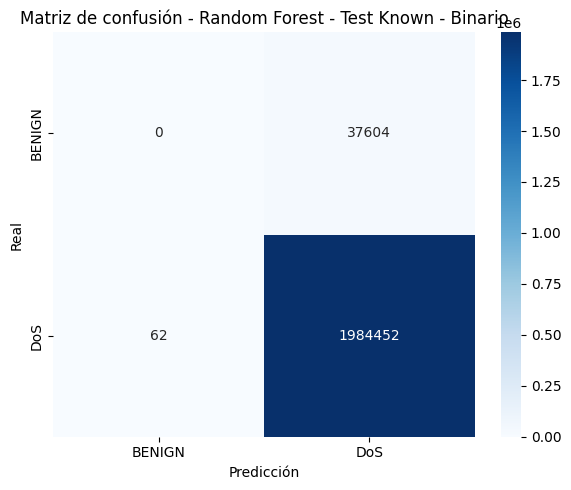


==== RANDOM FOREST + SIN BALANCEO - TEST ZERODAY (BINARIO) ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9993,0.9996,98418.0000
accuracy,0.9993,0.9993,0.9993,0.9993
macro avg,0.5000,0.4996,0.4998,98418.0000
weighted avg,1.0000,0.9993,0.9996,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [   73 98345]]

No se pudo calcular el area bajo la curva ROC


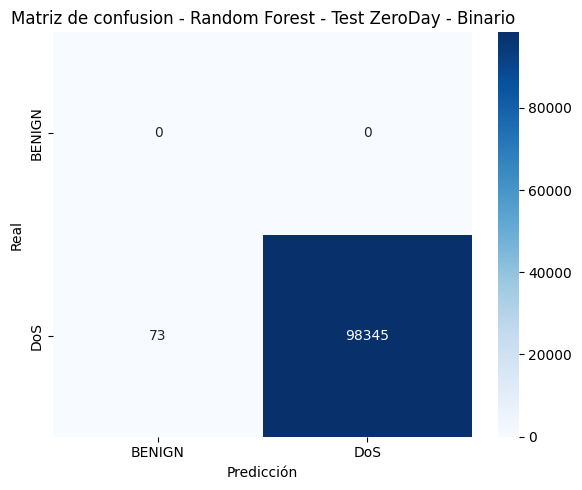

Tasa de detección de ataques ZeroDay - Binario: 0.9993


In [4]:
rf_pipe_binario_sin_balanceo = construccion_rf_pipeline(n_estimators=100, class_weight=None, n_jobs=-1, random_state=19)
rf_pipe_binario_sin_balanceo.fit(x_train_binario, y_train_binario)

print("\n==== RANDOM FOREST + SIN BALANCEO - VALIDACION (BINARIO) ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(rf_pipe_binario_sin_balanceo, x_val_binario, y_val_binario, carpeta_salida_rf_sin_balanceo_nithreshold, "roc_rf_val_binario_sin_balanceo.png", 0.5)

print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

print("\n==== RANDOM FOREST + SIN BALANCEO - TEST KNOWN (BINARIO) ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(rf_pipe_binario_sin_balanceo, x_test_known_binario, y_test_known_binario, carpeta_salida_rf_sin_balanceo_nithreshold, "roc_rf_test_known_binario_sin_balanceo.png", 0.5)

print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf_sin_balanceo_nithreshold, "matriz_confusion_rf_test_known_binario_sin_balanceo_nithreshold.png"))
plt.show()

print("\n==== RANDOM FOREST + SIN BALANCEO - TEST ZERODAY (BINARIO) ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario,matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(rf_pipe_binario_sin_balanceo, x_test_zeroday_binario, y_test_zeroday_binario, carpeta_salida_rf_sin_balanceo_nithreshold, "roc_rf_test_zeroday_binario_sin_balanceo.png", 0.5)


print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf_sin_balanceo_nithreshold, "matriz_confusion_rf_test_zeroday_binario_sin_balanceo_nithreshold.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")



## RANDOM FOREST SIN BALANCEO PERO CON THRESHOLD=0.8

In [5]:
carpeta_salida_rf_sin_balanceo_conthreshold = "Resultados_tipo_balanceo/RandomForest_sin_balanceo_con_threshold"
os.makedirs(carpeta_salida_rf_sin_balanceo_conthreshold, exist_ok=True)

Clasificador binario


==== RANDOM FOREST + SIN BALANCEO + THRESHOLD=0.8 - VALIDACION (BINARIO) ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.97      1.00      0.98    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.9346,0.9933,0.9631,1929.0000
1,1.0000,0.9998,0.9999,652147.0000
accuracy,0.9998,0.9998,0.9998,0.9998
macro avg,0.9673,0.9965,0.9815,654076.0000
weighted avg,0.9998,0.9998,0.9998,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1916     13]
 [   134 652013]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 0.999

==== RANDOM FOREST + SIN BALANCEO + THRESHOLD=0.8 - TEST KNOWN (BINARIO) ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.89      0.10      0.18     37604
           1       0.98      1.00      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.94      0.55      0.59   2022118
weighted avg       0.98      0.98      0.98   2022118



,precision,recall,f1-score,support
0,0.8902,0.1000,0.1798,37604.000
1,0.9832,0.9998,0.9914,1984514.000
accuracy,0.9830,0.9830,0.9830,0.983
macro avg,0.9367,0.5499,0.5856,2022118.000
weighted avg,0.9815,0.9830,0.9763,2022118.000



 Matriz de confusion - Test known - Binario:

[[   3761   33843]
 [    464 1984050]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.572


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

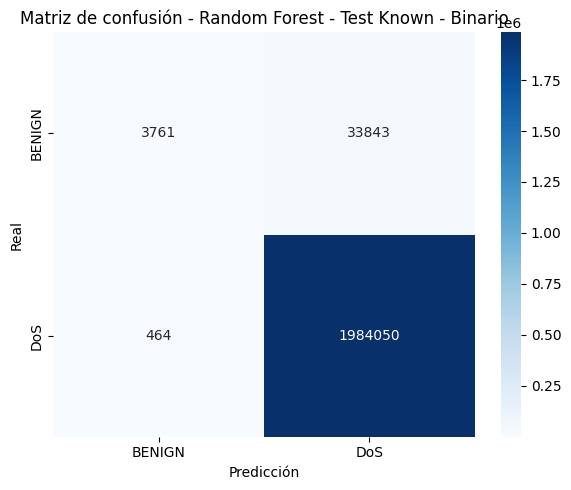


==== RANDOM FOREST + SIN BALANCEO + THRESHOLD=0.8 - TEST ZERODAY (BINARIO) ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9979,0.9989,98418.0000
accuracy,0.9979,0.9979,0.9979,0.9979
macro avg,0.5000,0.4989,0.4995,98418.0000
weighted avg,1.0000,0.9979,0.9989,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  208 98210]]

No se pudo calcular el area bajo la curva ROC


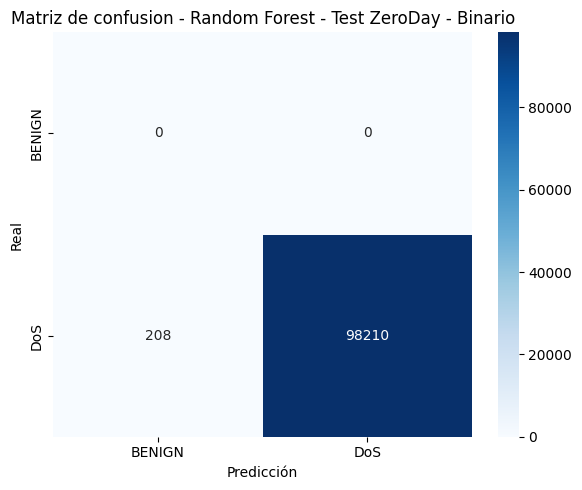

Tasa de detección de ataques ZeroDay - Binario: 0.9979


In [6]:
rf_pipe_binario_sin_balanceo = construccion_rf_pipeline(n_estimators=100, class_weight=None, n_jobs=-1, random_state=19)
rf_pipe_binario_sin_balanceo.fit(x_train_binario, y_train_binario)

print("\n==== RANDOM FOREST + SIN BALANCEO + THRESHOLD=0.8 - VALIDACION (BINARIO) ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(rf_pipe_binario_sin_balanceo, x_val_binario, y_val_binario, carpeta_salida_rf_sin_balanceo_conthreshold, "roc_rf_val_binario_sin_balanceo_conthreshold.png")

print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

print("\n==== RANDOM FOREST + SIN BALANCEO + THRESHOLD=0.8 - TEST KNOWN (BINARIO) ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(rf_pipe_binario_sin_balanceo, x_test_known_binario, y_test_known_binario, carpeta_salida_rf_sin_balanceo_conthreshold, "roc_rf_test_known_binario_sin_balanceo_conthreshold.png")

print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf_sin_balanceo_conthreshold, "matriz_confusion_rf_test_known_binario_sin_balanceo_conthreshold.png"))
plt.show()

print("\n==== RANDOM FOREST + SIN BALANCEO + THRESHOLD=0.8 - TEST ZERODAY (BINARIO) ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario,matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(rf_pipe_binario_sin_balanceo, x_test_zeroday_binario, y_test_zeroday_binario, carpeta_salida_rf_sin_balanceo_conthreshold, "roc_rf_test_zeroday_binario_sin_balanceo_conthreshold.png")


print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf_sin_balanceo_conthreshold, "matriz_confusion_rf_test_zeroday_binario_sin_balanceo_conthreshold.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")



Clasificador Multiclase

In [ ]:
# MULTICLASE
rf_pipe_multiclase_sin_balanceo = construccion_rf_pipeline(n_estimators=100, class_weight=None, n_jobs=-1, random_state=19)
rf_pipe_multiclase_sin_balanceo.fit(x_train_multiclase, y_train_multiclase)
clases_multiclase = rf_pipe_multiclase_sin_balanceo.named_steps["rf"].classes_

print("\n==== RANDOM FOREST + SIN BALANCEO - VALIDACION (MULTICLASE) ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase_sin_balanceo, x_val_multiclase, y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

if not np.isnan(auc_val_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_val_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

print("\n==== RANDOM FOREST + SIN BALANCEO - TEST KNOWN (MULTICLASE) ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase_sin_balanceo, x_test_known_multiclase, y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

if not np.isnan(auc_test_known_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_test_known_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf_sin_balanceo}/matriz_confusion_rf_test_known_multiclase_sin_balanceo.png")
plt.show()

print("\n==== RANDOM FOREST + SIN BALANCEO - TEST ZERODAY (MULTICLASE) ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase_sin_balanceo, x_test_zeroday_multiclase, y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

if not np.isnan(auc_test_zeroday_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test ZeroDay - Multiclase: {auc_test_zeroday_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf_sin_balanceo}/matriz_confusion_rf_test_zeroday_multiclase_sin_balanceo.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

KeyboardInterrupt: 

## Random Forest con balanceo y threshold=0.8

In [7]:
from Scripts_modelos_supervisados.randomforest import construccion_rf_pipeline, evaluar_rf_binario, evaluar_rf_multiclase, construccion_rf_pipeline_smote

carpeta_salida_rf = "Resultados_tipo_balanceo/RandomForest_con_balanceo"
os.makedirs(carpeta_salida_rf, exist_ok=True)

Clasificador Binario


==== RANDOM FOREST - VALIDACION - CON BALANCEO + THRESHOLD=0.8 - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.97      0.99      0.98    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.9376,0.9896,0.9629,1929.0000
1,1.0000,0.9998,0.9999,652147.0000
accuracy,0.9998,0.9998,0.9998,0.9998
macro avg,0.9688,0.9947,0.9814,654076.0000
weighted avg,0.9998,0.9998,0.9998,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1909     20]
 [   127 652020]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 0.999

==== RANDOM FOREST - TEST KNOWN - CON BALANCEO + THRESHOLD=0.8 - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.91      0.09      0.17     37604
           1       0.98      1.00      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.95      0.55      0.58   2022118
weighted avg       0.98      0.98      0.98   2022118



,precision,recall,f1-score,support
0,0.9128,0.0940,0.1705,37604.000
1,0.9831,0.9998,0.9914,1984514.000
accuracy,0.9830,0.9830,0.9830,0.983
macro avg,0.9479,0.5469,0.5810,2022118.000
weighted avg,0.9818,0.9830,0.9761,2022118.000



 Matriz de confusion - Test known - Binario:

[[   3536   34068]
 [    338 1984176]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.547


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

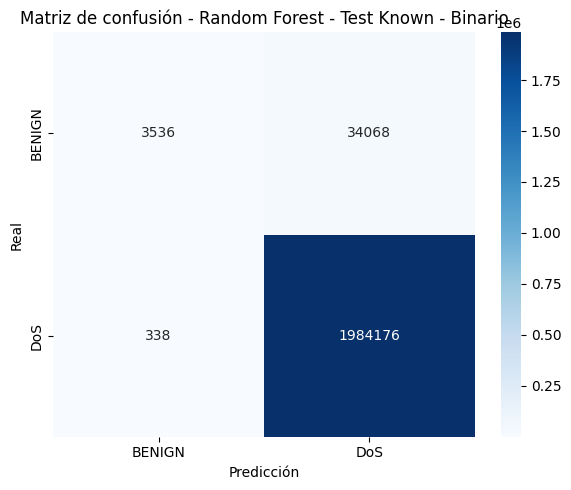


==== RANDOM FOREST - TEST ZERODAY - CON BALANCEO + THRESHOLD=0.8 - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9981,0.9990,98418.0000
accuracy,0.9981,0.9981,0.9981,0.9981
macro avg,0.5000,0.4990,0.4995,98418.0000
weighted avg,1.0000,0.9981,0.9990,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  191 98227]]

No se pudo calcular el area bajo la curva ROC


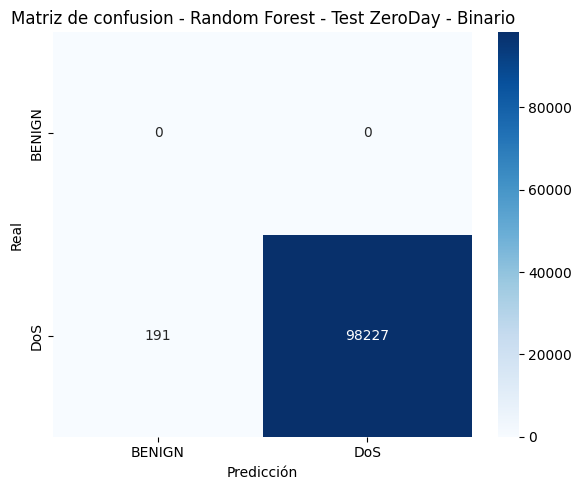

Tasa de detección de ataques ZeroDay - Binario: 0.9981


In [8]:
rf_pipe_binario = construccion_rf_pipeline(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=19)
rf_pipe_binario.fit(x_train_binario, y_train_binario)

# VALIDACION
print("\n==== RANDOM FOREST - VALIDACION - CON BALANCEO + THRESHOLD=0.8 - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_rf,
    "roc_rf_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== RANDOM FOREST - TEST KNOWN - CON BALANCEO + THRESHOLD=0.8 - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_rf,
    "roc_rf_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== RANDOM FOREST - TEST ZERODAY - CON BALANCEO + THRESHOLD=0.8 - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_rf, 
    "roc_rf_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

Clasificador Multiclase

In [ ]:
# MULTICLASE
rf_pipe_multiclase = construccion_rf_pipeline(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=19)
rf_pipe_multiclase.fit(x_train_multiclase, y_train_multiclase)

print("\n==== RANDOM FOREST - VALIDACION (MULTICLASE) ====")
reporte_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase, x_val_multiclase, y_val_multiclase, carpeta_salida_rf, "roc_rf_val_multiclase.png")

print("\n==== RANDOM FOREST - TEST KNOWN (MULTICLASE) ====")
reporte_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase, x_test_known_multiclase, y_test_known_multiclase, carpeta_salida_rf, "roc_rf_test_known_multiclase.png")

print("\n==== RANDOM FOREST - TEST ZERODAY (MULTICLASE) ====")
reporte_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase, x_test_zeroday_multiclase, y_test_zeroday_multiclase, carpeta_salida_rf, "roc_rf_test_zeroday_multiclase.png")

#Matriz de confusion 
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest (Multiclase) - Test Known")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_multiclase_test_known.png")
plt.show()

## Random Forest con Undersampling 1:1 y balanceo de clases

In [4]:
from Scripts_modelos_supervisados.randomforest import construccion_rf_pipeline, evaluar_rf_binario, evaluar_rf_multiclase, construccion_rf_pipeline_smote

carpeta_salida_rf = "Resultados_tipo_balanceo/RandomForest_con_undersampling"
os.makedirs(carpeta_salida_rf, exist_ok=True)

#UNDERSAMPLING 1:1

# 1-Unimos X e Y para poder muestrear comodamente
df_train_binario = x_train_binario.copy()
df_train_binario["Binary_label"] = y_train_binario.values

# 2-Separamos clases
df_benigno = df_train_binario[df_train_binario["Binary_label"] == 0].copy()
df_ataque = df_train_binario[df_train_binario["Binary_label"] == 1].copy()

# 3-Undersampling de la clase mayoritaria (ataques)
df_ataque_muestras = df_ataque.sample(n=len(df_benigno), random_state=19)

# 4-Unimos benignos + ataques muestreados
df_train = pd.concat([df_benigno, df_ataque_muestras], axis=0)

# 5-Mezclamos filas
df_train = df_train.sample(frac=1, random_state=19).reset_index(drop=True)

# 6-Volvemos a separar X e Y
x_train_binario_undersampling = df_train.drop(columns=["Binary_label"])
y_train_binario_undersampling = df_train["Binary_label"]

print("\nDistribución train binario con undersampling:")
print(y_train_binario_undersampling.value_counts())
print("\nTamaño de X:", x_train_binario_undersampling.shape)
print("Tamaño de Y:", y_train_binario_undersampling.shape)


Distribución train binario con undersampling:
Binary_label
0    17362
1    17362
Name: count, dtype: int64

Tamaño de X: (34724, 38)
Tamaño de Y: (34724,)


Clasificador Binario


==== RANDOM FOREST - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.52      1.00      0.69      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.76      1.00      0.84    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.5239,1.0000,0.6876,1929.0000
1,1.0000,0.9973,0.9987,652147.0000
accuracy,0.9973,0.9973,0.9973,0.9973
macro avg,0.7620,0.9987,0.8431,654076.0000
weighted avg,0.9986,0.9973,0.9977,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1929      0]
 [  1753 650394]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 1.000

==== RANDOM FOREST - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.33      0.28      0.30     37604
           1       0.99      0.99      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.66      0.64      0.65   2022118
weighted avg       0.97      0.98      0.98   2022118



,precision,recall,f1-score,support
0,0.3289,0.2821,0.3037,3.760400e+04
1,0.9864,0.9891,0.9878,1.984514e+06
accuracy,0.9759,0.9759,0.9759,9.759000e-01
macro avg,0.6577,0.6356,0.6457,2.022118e+06
weighted avg,0.9742,0.9759,0.9750,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[  10608   26996]
 [  21646 1962868]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.932


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

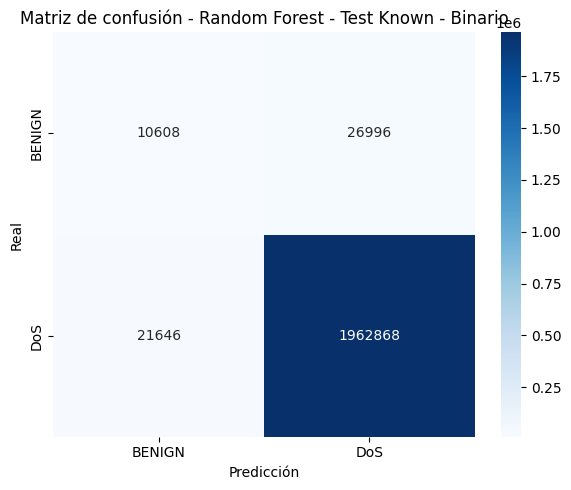


==== RANDOM FOREST - TEST ZERODAY - BINARIO ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9967,0.9984,98418.0000
accuracy,0.9967,0.9967,0.9967,0.9967
macro avg,0.5000,0.4984,0.4992,98418.0000
weighted avg,1.0000,0.9967,0.9984,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  320 98098]]

No se pudo calcular el area bajo la curva ROC


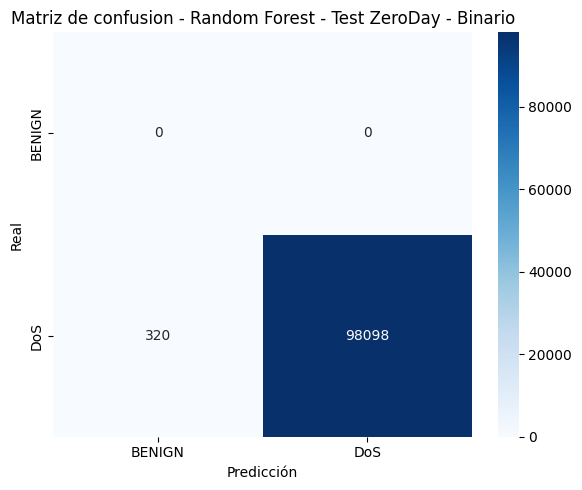

Tasa de detección de ataques ZeroDay - Binario: 0.9967


In [5]:
rf_pipe_binario = construccion_rf_pipeline(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=19)
rf_pipe_binario.fit(x_train_binario_undersampling, y_train_binario_undersampling)

# VALIDACION
print("\n==== RANDOM FOREST - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_rf,
    "roc_rf_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== RANDOM FOREST - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_rf,
    "roc_rf_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_test_known_binario.png"))
plt.show()

# TEST ZERODAY
print("\n==== RANDOM FOREST - TEST ZERODAY - BINARIO ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(
    rf_pipe_binario,
    x_test_zeroday_binario,
    y_test_zeroday_binario,
    carpeta_salida_rf, 
    "roc_rf_test_zeroday_binario.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf, "matriz_confusion_rf_test_zeroday_binario.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

Clasificador Multiclase

In [ ]:
rf_pipe_multiclase = construccion_rf_pipeline(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=19)
rf_pipe_multiclase.fit(x_train_multiclase, y_train_multiclase)
clases_multiclase = rf_pipe_multiclase.named_steps["rf"].classes_

# VALIDACION
print("\n==== RANDOM FOREST - VALIDACION - MULTICLASE ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_rf_multiclase(
    rf_pipe_multiclase, 
    x_val_multiclase, 
    y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

if not np.isnan(auc_val_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_val_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

# TEST KNOWN
print("\n==== RANDOM FOREST - TEST KNOWN - MULTICLASE ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_rf_multiclase(
    rf_pipe_multiclase, 
    x_test_known_multiclase, 
    y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

if not np.isnan(auc_test_known_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_test_known_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_test_known_multiclase.png")
plt.show()

# TEST ZERODAY
print("\n==== RANDOM FOREST - TEST ZERODAY - MULTICLASE ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_rf_multiclase(
    rf_pipe_multiclase, 
    x_test_zeroday_multiclase, 
    y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

if not np.isnan(auc_test_zeroday_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test ZeroDay - Multiclase: {auc_test_zeroday_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf}/matriz_confusion_rf_test_zeroday_multiclase.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")

### Random Forest con SMOTE

In [2]:
from Scripts_modelos_supervisados.randomforest import  evaluar_rf_binario, evaluar_rf_multiclase, construccion_rf_pipeline_smote

carpeta_salida_rf_smote = "Resultados_tipo_balanceo/RandomForest_SMOTE"
os.makedirs(carpeta_salida_rf_smote, exist_ok=True)

Clasificador Binario


==== RANDOM FOREST + SMOTE - VALIDACION (BINARIO) ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.95      1.00      0.97    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.9072,0.9938,0.9485,1929.0000
1,1.0000,0.9997,0.9998,652147.0000
accuracy,0.9997,0.9997,0.9997,0.9997
macro avg,0.9536,0.9967,0.9742,654076.0000
weighted avg,0.9997,0.9997,0.9997,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1917     12]
 [   196 651951]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 0.999

==== RANDOM FOREST + SMOTE - TEST KNOWN (BINARIO) ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.84      0.08      0.15     37604
           1       0.98      1.00      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.91      0.54      0.57   2022118
weighted avg       0.98      0.98      0.98   2022118



,precision,recall,f1-score,support
0,0.8353,0.0849,0.1542,3.760400e+04
1,0.9830,0.9997,0.9912,1.984514e+06
accuracy,0.9827,0.9827,0.9827,9.827000e-01
macro avg,0.9091,0.5423,0.5727,2.022118e+06
weighted avg,0.9802,0.9827,0.9757,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[   3194   34410]
 [    630 1983884]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.560


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

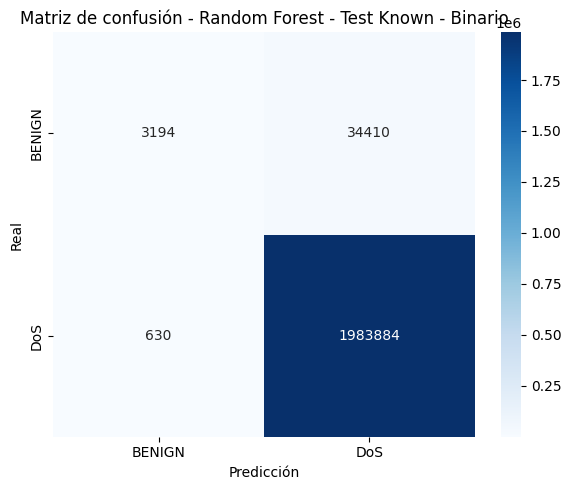


==== RANDOM FOREST + SMOTE - TEST ZERODAY (BINARIO) ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9977,0.9989,98418.0000
accuracy,0.9977,0.9977,0.9977,0.9977
macro avg,0.5000,0.4989,0.4994,98418.0000
weighted avg,1.0000,0.9977,0.9989,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  224 98194]]

No se pudo calcular el area bajo la curva ROC


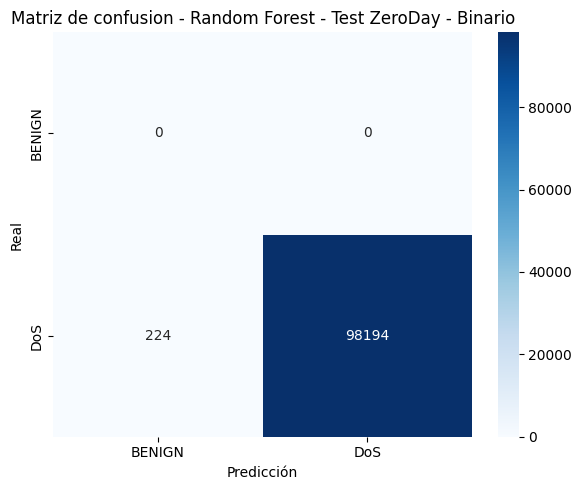

Tasa de detección de ataques ZeroDay - Binario: 0.9977


In [3]:
rf_pipe_binario_smote = construccion_rf_pipeline_smote(n_estimators=100, class_weight=None, n_jobs=-1, random_state=19)
rf_pipe_binario_smote.fit(x_train_binario, y_train_binario)

print("\n==== RANDOM FOREST + SMOTE - VALIDACION (BINARIO) ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(rf_pipe_binario_smote, x_val_binario, y_val_binario, carpeta_salida_rf_smote, "roc_rf_val_binario_smote.png")

print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

print("\n==== RANDOM FOREST + SMOTE - TEST KNOWN (BINARIO) ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(rf_pipe_binario_smote, x_test_known_binario, y_test_known_binario, carpeta_salida_rf_smote, "roc_rf_test_known_binario_smote.png")

print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf_smote, "matriz_confusion_rf_test_known_binario_smote.png"))
plt.show()

print("\n==== RANDOM FOREST + SMOTE - TEST ZERODAY (BINARIO) ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(rf_pipe_binario_smote, x_test_zeroday_binario, y_test_zeroday_binario, carpeta_salida_rf_smote, "roc_rf_test_zeroday_binario_smote.png")


print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf_smote, "matriz_confusion_rf_test_zeroday_binario_smote.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")



Clasificador Binario con threshold 0.5


==== RANDOM FOREST + SMOTE - VALIDACION (BINARIO) ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.98      0.99      0.98    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.9537,0.9813,0.9673,1929.0000
1,0.9999,0.9999,0.9999,652147.0000
accuracy,0.9998,0.9998,0.9998,0.9998
macro avg,0.9768,0.9906,0.9836,654076.0000
weighted avg,0.9998,0.9998,0.9998,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1893     36]
 [    92 652055]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 0.999

==== RANDOM FOREST + SMOTE - TEST KNOWN (BINARIO) ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     37604
           1       0.98      1.00      0.99   1984514

    accuracy                           0.98   2022118
   macro avg       0.49      0.50      0.50   2022118
weighted avg       0.96      0.98      0.97   2022118



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,3.760400e+04
1,0.9814,0.9999,0.9906,1.984514e+06
accuracy,0.9813,0.9813,0.9813,9.813000e-01
macro avg,0.4907,0.5000,0.4953,2.022118e+06
weighted avg,0.9632,0.9813,0.9722,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[      0   37604]
 [    152 1984362]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.560


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

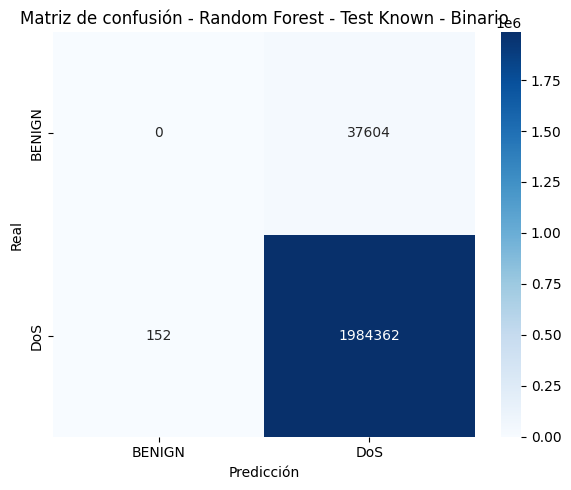


==== RANDOM FOREST + SMOTE - TEST ZERODAY (BINARIO) ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     98418

    accuracy                           1.00     98418
   macro avg       0.50      0.50      0.50     98418
weighted avg       1.00      1.00      1.00     98418



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9986,0.9993,98418.0000
accuracy,0.9986,0.9986,0.9986,0.9986
macro avg,0.5000,0.4993,0.4996,98418.0000
weighted avg,1.0000,0.9986,0.9993,98418.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  138 98280]]

No se pudo calcular el area bajo la curva ROC


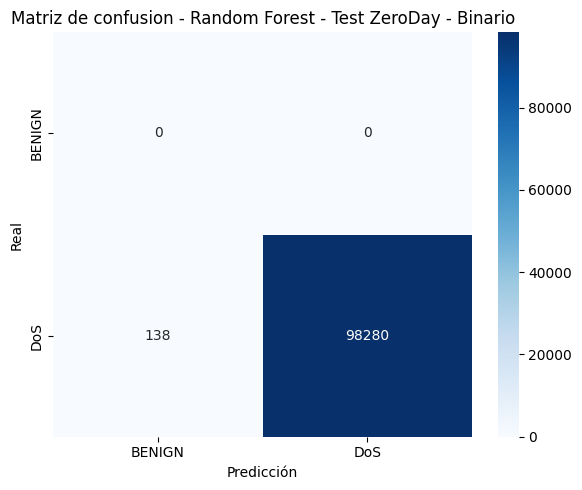

Tasa de detección de ataques ZeroDay - Binario: 0.9986


In [6]:
print("\n==== RANDOM FOREST + SMOTE - VALIDACION (BINARIO) ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_rf_binario(rf_pipe_binario_smote, x_val_binario, y_val_binario, carpeta_salida_rf_smote, "roc_rf_val_binario_smote_threshold_05.png", 0.5)

print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

print("\n==== RANDOM FOREST + SMOTE - TEST KNOWN (BINARIO) ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_rf_binario(rf_pipe_binario_smote, x_test_known_binario, y_test_known_binario, carpeta_salida_rf_smote, "roc_rf_test_known_binario_smote_threshold_05.png", 0.5)

print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf_smote, "matriz_confusion_rf_test_known_binario_smote_threshold_05.png"))
plt.show()

print("\n==== RANDOM FOREST + SMOTE - TEST ZERODAY (BINARIO) ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_rf_binario(rf_pipe_binario_smote, x_test_zeroday_binario, y_test_zeroday_binario, carpeta_salida_rf_smote, "roc_rf_test_zeroday_binario_smote_threshold_05.png", 0.5)


print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_rf_smote, "matriz_confusion_rf_test_zeroday_binario_smote_threshold_05.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay - Binario: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

Clasificador Multiclase

In [ ]:
# MULTICLASE
rf_pipe_multiclase_smote = construccion_rf_pipeline_smote(n_estimators=100, class_weight=None, n_jobs=-1, random_state=19)
rf_pipe_multiclase_smote.fit(x_train_multiclase, y_train_multiclase)
clases_multiclase = rf_pipe_multiclase_smote.named_steps["rf"].classes_

print("\n==== RANDOM FOREST + SMOTE - VALIDACION (MULTICLASE) ====")
reporte_texto_val_multiclase, reporte_dict_val_multiclase, matriz_val_multiclase, auc_val_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase_smote, x_val_multiclase, y_val_multiclase)

print("Informe de clasificacion - Validacion - Multiclase:\n")
print(reporte_texto_val_multiclase)
display(pd.DataFrame(reporte_dict_val_multiclase).transpose().round(4))
print("\nMatriz de confusion - Validacion - Multiclase:\n")
print(matriz_val_multiclase)

if not np.isnan(auc_val_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_val_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

print("\n==== RANDOM FOREST + SMOTE - TEST KNOWN (MULTICLASE) ====")
reporte_texto_test_known_multiclase, reporte_dict_test_known_multiclase, matriz_test_known_multiclase, auc_test_known_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase_smote, x_test_known_multiclase, y_test_known_multiclase)

print("Informe de clasificacion - Test Known - Multiclase:\n")
print(reporte_texto_test_known_multiclase)
display(pd.DataFrame(reporte_dict_test_known_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test Known - Multiclase:\n")
print(matriz_test_known_multiclase)

if not np.isnan(auc_test_known_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Validacion - Multiclase: {auc_test_known_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Known
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_known_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test Known - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf_smote}/matriz_confusion_rf_test_known_multiclase_smote.png")
plt.show()

print("\n==== RANDOM FOREST + SMOTE - TEST ZERODAY (MULTICLASE) ====")
reporte_texto_test_zeroday_multiclase, reporte_dict_test_zeroday_multiclase, matriz_test_zeroday_multiclase, auc_test_zeroday_multiclase = evaluar_rf_multiclase(rf_pipe_multiclase_smote, x_test_zeroday_multiclase, y_test_zeroday_multiclase)

print("Informe de clasificacion - Test ZeroDay - Multiclase:\n")
print(reporte_texto_test_zeroday_multiclase)
display(pd.DataFrame(reporte_dict_test_zeroday_multiclase).transpose().round(4))
print("\nMatriz de confusion - Test ZeroDay - Multiclase:\n")
print(matriz_test_zeroday_multiclase)

if not np.isnan(auc_test_zeroday_multiclase):
    print(f"\nArea bajo la curva ROC (AUC macro OvR) - Test ZeroDay - Multiclase: {auc_test_zeroday_multiclase:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC (AUC macro OvR)")

#Matriz de confusion multiclase - Test Zeroday
plt.figure(figsize=(10,7))
sns.heatmap(matriz_test_zeroday_multiclase, annot=True, fmt='d', cmap='Blues', xticklabels=clases_multiclase, yticklabels=clases_multiclase)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Random Forest - Test ZeroDay - Multiclase")
plt.tight_layout()
plt.savefig(f"{carpeta_salida_rf_smote}/matriz_confusion_rf_test_zeroday_multiclase_smote.png")
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador multiclase
indice_clase_real = list(clases_multiclase).index("DoS")
indice_benigno = list(clases_multiclase).index("Benign")
total_zeroday = matriz_test_zeroday_multiclase[indice_clase_real, :].sum()

predichas_como_benigno = matriz_test_zeroday_multiclase[indice_clase_real, indice_benigno]
detectadas_como_ataque = total_zeroday - predichas_como_benigno

if total_zeroday > 0:
    tasa_deteccion_zeroday = detectadas_como_ataque / total_zeroday
    print(f"Tasa de detección de ataques ZeroDay (Multiclase): {tasa_deteccion_zeroday:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador multiclase.")